In [89]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os

In [4]:
os.chdir('..')

In [5]:
os.getcwd()

'/Users/ak/Documents/GitHub/entropy-trading'

In [6]:
from data import data_loader
from features import tstat, volatility
from regime import state_labels

df = data_loader.get_data()
df = tstat.compute_tstat(df)
df = volatility.compute_volatility(df)
df = state_labels.label_volatility(df)
df = state_labels.label_regime(df)
df = state_labels.smooth_regime(df)

[*********************100%***********************]  1 of 1 completed


In [7]:
df.head()

,Price,Log Return,Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,,
2008-01-03,103.445656,-0.000483,NaN,NaN,NaN,0,NaN
2008-01-04,100.910561,-0.024812,-0.024507,NaN,NaN,0,NaN
2008-01-07,100.824898,-0.000849,-0.000849,NaN,NaN,0,NaN
2008-01-08,99.196701,-0.016281,-0.016149,NaN,NaN,0,NaN
2008-01-09,100.239311,0.010456,0.010511,NaN,NaN,0,0.0


In [8]:
df.tail()

,Price,Log Return,Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,,
2017-12-22,235.453140,-0.000262,-0.000262,2.310020,0.003561,0,1.0
2017-12-26,235.171509,-0.001197,-0.001196,2.250610,0.003566,0,1.0
2017-12-27,235.285950,0.000487,0.000487,2.221702,0.003566,0,1.0
2017-12-28,235.769974,0.002055,0.002057,2.298740,0.003542,0,1.0
2017-12-29,234.881027,-0.003778,-0.003770,2.209388,0.003541,0,1.0


In [9]:
df[['Log Return', 'T-Stat_200', 'Volatility', 'Vol State', 'Regime']].tail(10)

,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,
2017-12-15,0.008293,2.033894,0.003381,0,1.0
2017-12-18,0.006321,2.143430,0.003474,0,1.0
2017-12-19,-0.003848,2.290367,0.003533,0,1.0
2017-12-20,-0.000524,2.274187,0.003570,0,1.0
2017-12-21,0.002057,2.297565,0.003576,0,1.0
2017-12-22,-0.000262,2.310020,0.003561,0,1.0
2017-12-26,-0.001197,2.250610,0.003566,0,1.0
2017-12-27,0.000487,2.221702,0.003566,0,1.0
2017-12-28,0.002055,2.298740,0.003542,0,1.0


In [10]:
df[['Vol State', 'Regime']].dropna().dtypes

Vol State      int64
Regime       float64
dtype: object

In [11]:
df['Log Return'].std()

0.012807890315472433

In [12]:
df['T-Stat_200'].describe()

count    2317.000000
mean        0.843341
std         0.904355
min        -1.691399
25%         0.220200
50%         0.904598
75%         1.585432
max         2.575030
Name: T-Stat_200, dtype: float64

In [13]:
df['Volatility'].describe()

count    2457.000000
mean        0.010660
std         0.007262
min         0.003136
25%         0.006815
50%         0.008264
75%         0.012081
max         0.047614
Name: Volatility, dtype: float64

In [14]:
df.isna().sum()

Price           0
Log Return      0
Return          1
T-Stat_200    200
Volatility     60
Vol State       0
Regime          4
dtype: int64

In [15]:
df['Regime'].value_counts(normalize = True)

Regime
 1.0    0.757262
-1.0    0.163152
 0.0    0.079586
Name: proportion, dtype: float64

In [16]:
df['Vol State'].value_counts(normalize = True)

Vol State
0    0.810886
1    0.189114
Name: proportion, dtype: float64

<Axes: xlabel='Date', ylabel='T-Stat_200'>

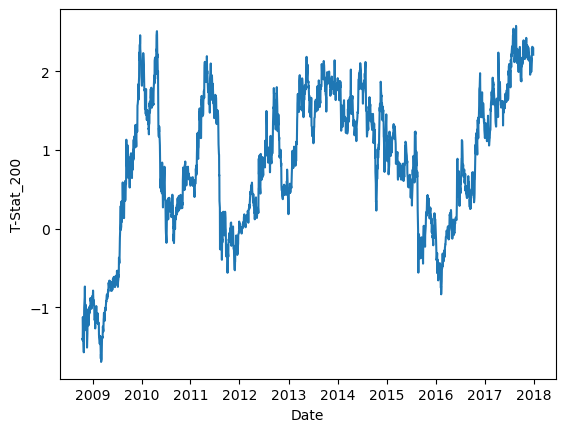

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data = df['T-Stat_200'])

<Axes: xlabel='Date', ylabel='Volatility'>

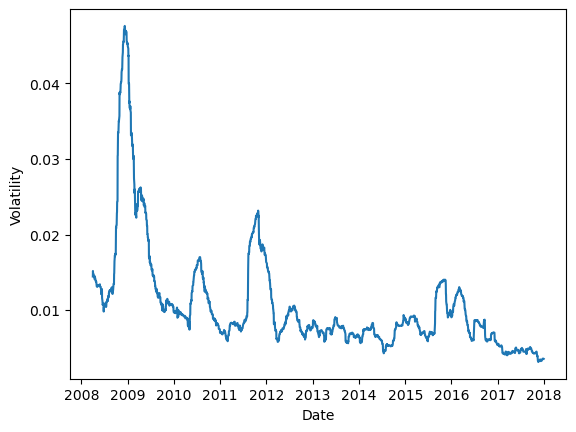

In [18]:
sns.lineplot(data = df['Volatility'])

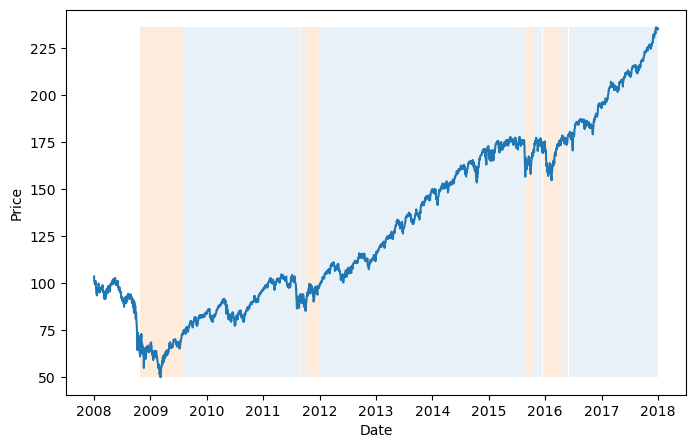

In [19]:
fig, ax = plt.subplots(figsize = (8, 5))
sns.lineplot(data = df['Price'], ax = ax)
ax.fill_between(df.index, df['Price'].min(), df['Price'].max(), where = (df['Regime'] == 1), alpha = 0.1, label = 'Bull')
ax.fill_between(df.index, df['Price'].min(), df['Price'].max(), where = (df['Regime'] == -1), alpha = 0.15, label = 'Bear')

In [20]:
df['Forward Return'] = df['Log Return'].shift(-1)
df_new = df.dropna(subset = ['Forward Return'])

bull_mean = df_new.loc[df['Regime'] == 1, 'Forward Return'].mean()
neutral_mean = df_new.loc[df['Regime'] == 0, 'Forward Return'].mean()
bear_mean = df_new.loc[df['Regime'] == -1, 'Forward Return'].mean()

print(bull_mean)
print(neutral_mean)
print(bear_mean)

df_new.loc[df_new['Regime'] == -1, 'Forward Return'].describe()

0.0004602072066016652
-0.0020508466171539536
0.0009423753562007526


count    410.000000
mean       0.000942
std        0.020286
min       -0.092749
25%       -0.009381
50%        0.000948
75%        0.010603
max        0.110517
Name: Forward Return, dtype: float64

In [21]:
df_new.groupby('Regime')['Forward Return'].std()

Regime
-1.0    0.020286
 0.0    0.021985
 1.0    0.008760
Name: Forward Return, dtype: float64

In [22]:
import numpy as np

bear_forward = df_new.loc[df_new['Regime'] == -1, 'Forward Return']

t = bear_forward.mean() / (bear_forward.std() / np.sqrt(len(bear_forward)))
print(t)

0.9406236725021461


In [23]:
bull_forward = df_new.loc[df_new['Regime'] == 1, 'Forward Return']

t = bull_forward.mean() / (bull_forward.std() / np.sqrt(len(bull_forward)))
print(t)

2.291027171252839


In [24]:
neutral_forward = df_new.loc[df_new['Regime'] == 0, 'Forward Return']

t = neutral_forward.mean() / (neutral_forward.std() / np.sqrt(len(neutral_forward)))
print(t)

-1.3192116742764035


In [25]:
df['Forward Vol'] = df['Volatility'].shift(-1)
df_new = df.dropna(subset =['Forward Vol'])

df_new.groupby('Vol State')['Forward Vol'].mean()

Vol State
0    0.010171
1    0.012696
Name: Forward Vol, dtype: float64

In [26]:
from regime import matrix

df = matrix.initialize_state(df)

transition_matrix = matrix.build_stationary_matrix(df)
print(transition_matrix)

Next State    -1.0_0    -1.0_1  0.0_0     1.0_0     1.0_1  nan_0
State                                                           
-1.0_0      0.976190  0.003968  0.000  0.019841  0.000000   0.00
-1.0_1      0.025316  0.962025  0.000  0.000000  0.012658   0.00
0.0_0       0.005000  0.000000  0.995  0.000000  0.000000   0.00
1.0_0       0.000631  0.000631  0.000  0.989899  0.008838   0.00
1.0_1       0.000000  0.012579  0.000  0.037736  0.949686   0.00
nan_0       0.000000  0.000000  0.250  0.000000  0.000000   0.75


In [27]:
from regime import entropy

entropy_vector = entropy.find_entropy_vector(transition_matrix)
print(entropy_vector)

State
-1.0_0    0.123244
-1.0_1    0.185625
0.0_0     0.031479
1.0_0     0.061146
1.0_1     0.227734
nan_0     0.562335
dtype: float64


<Axes: xlabel='Date', ylabel='Stationary Entropy'>

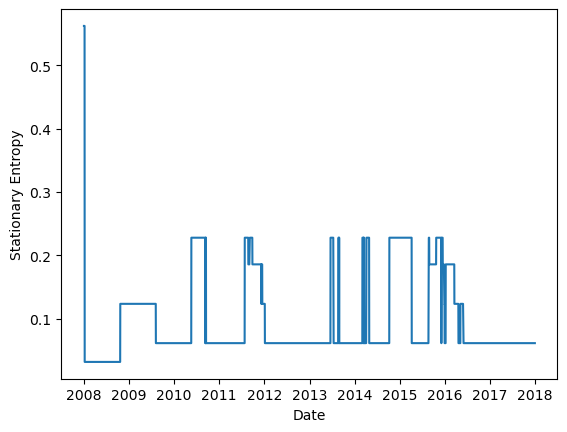

In [28]:
df = entropy.build_stationary_entropy(df, entropy_vector)

sns.lineplot(data = df['Stationary Entropy'])

<Axes: xlabel='Date', ylabel='Rolling Entropy'>

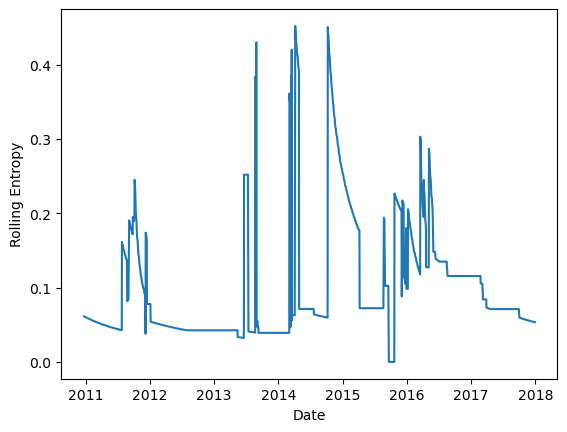

In [29]:
df = entropy.build_rolling_entropy(df)

sns.lineplot(data = df['Rolling Entropy'])

In [30]:
df['Rolling Entropy'].describe()

count    1767.000000
mean        0.099277
std         0.081014
min        -0.000000
25%         0.044295
50%         0.071073
75%         0.115509
max         0.452021
Name: Rolling Entropy, dtype: float64

In [31]:
df[[f'T-Stat_200', 'Log Return']].corr()

,T-Stat_200,Log Return
T-Stat_200,1.00000,-0.02669
Log Return,-0.02669,1.00000


In [32]:
df[['Volatility', 'Log Return']].corr()

,Volatility,Log Return
Volatility,1.000000,-0.017795
Log Return,-0.017795,1.000000


In [33]:
df[[f'T-Stat_200', 'Forward Return']].corr()

,T-Stat_200,Forward Return
T-Stat_200,1.000000,-0.023142
Forward Return,-0.023142,1.000000


In [34]:
df[['Volatility', 'Forward Return']].corr()

,Volatility,Forward Return
Volatility,1.000000,-0.019585
Forward Return,-0.019585,1.000000


In [35]:
from backtests import exposure

df = exposure.normalize_entropy(df)
df = exposure.normalize_tstat(df)
df = exposure.create_exposure(df)

In [36]:
df['Exposure'].describe()

count    2497.000000
mean        0.156604
std         0.358041
min        -0.837511
25%        -0.109348
50%         0.182120
75%         0.433822
max         0.938903
Name: Exposure, dtype: float64

In [37]:
(df['Exposure'].abs() > 0.8).mean()

np.float64(0.01748112832737386)

In [38]:
df['Trend'].describe()

count    2497.000000
mean        0.172856
std         0.393803
min        -0.837511
25%        -0.128521
50%         0.202310
75%         0.467678
max         0.938903
Name: Trend, dtype: float64

In [39]:
df['Confidence'].describe()

count    2517.000000
mean        0.905448
std         0.105298
min         0.454190
25%         0.882347
50%         0.933183
75%         1.000000
max         1.000000
Name: Confidence, dtype: float64

In [40]:
df['Exposure'].autocorr(lag = 1)

np.float64(0.9360256982776174)

In [41]:
df[['Exposure', 'Log Return']].corr()

,Exposure,Log Return
Exposure,1.000000,-0.019929
Log Return,-0.019929,1.000000


In [42]:
df[['Exposure', 'Forward Return']].corr()

,Exposure,Forward Return
Exposure,1.000000,-0.009856
Forward Return,-0.009856,1.000000


In [43]:
df.groupby('Vol State')['Exposure'].mean()

Vol State
0    0.192561
1    0.003939
Name: Exposure, dtype: float64

In [44]:
df.groupby('Regime')['Exposure'].mean()

Regime
-1.0    0.034906
 0.0   -0.119185
 1.0    0.209490
Name: Exposure, dtype: float64

In [45]:
df['Exposure Change'] = df['Exposure'].diff().abs()
df['Exposure Change'].mean()

np.float64(0.09579394626638299)

Text(0, 0.5, 'Exposure')

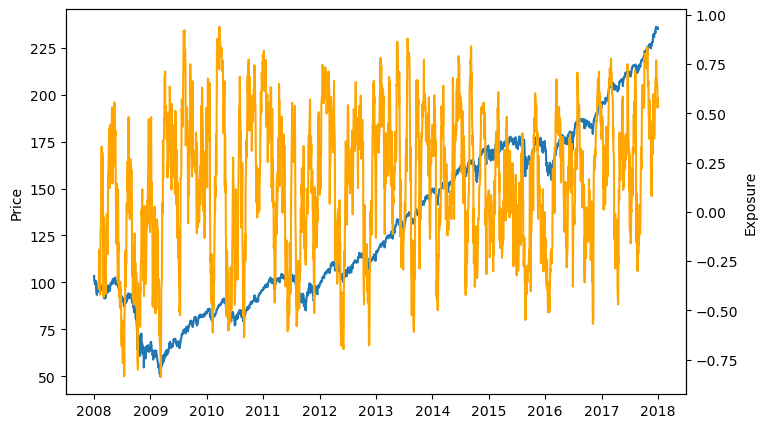

In [46]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['Price'], label = 'Price')
ax1.set_ylabel('Price')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

Text(0, 0.5, 'Exposure')

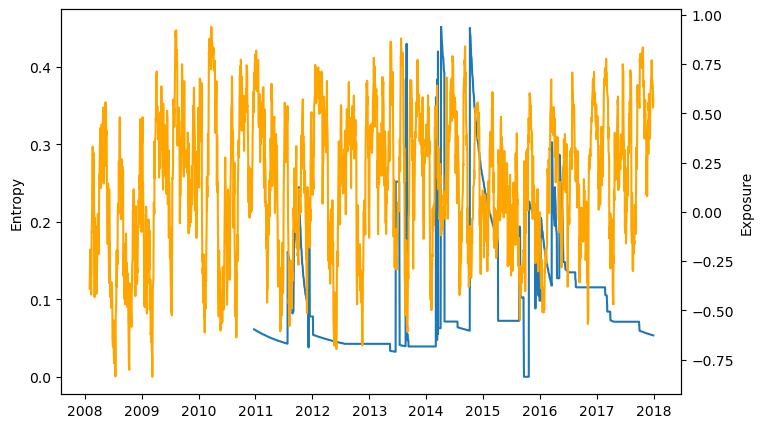

In [47]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['Rolling Entropy'], label = 'Entropy')
ax1.set_ylabel('Entropy')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

Text(0, 0.5, 'Exposure')

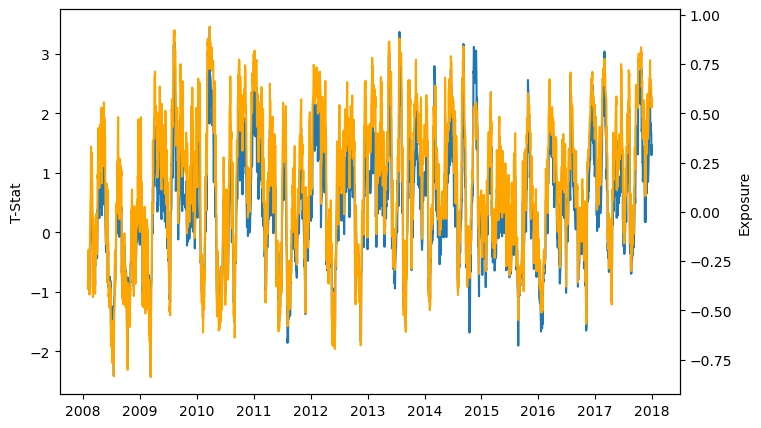

In [48]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['T-Stat_20'], label = 'T-Stat-20')
ax1.set_ylabel('T-Stat')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

<Axes: xlabel='Date'>

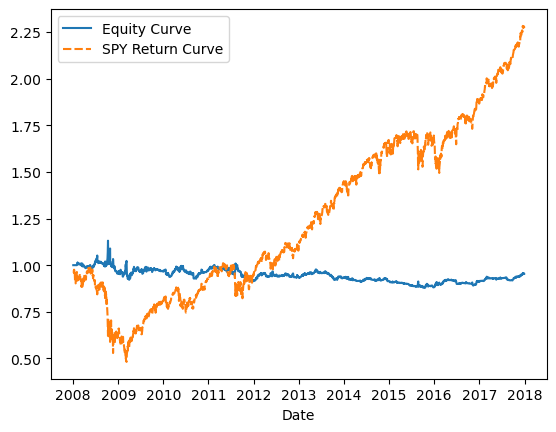

In [49]:
from backtests import backtest

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

<Axes: xlabel='Date', ylabel='Exposure'>

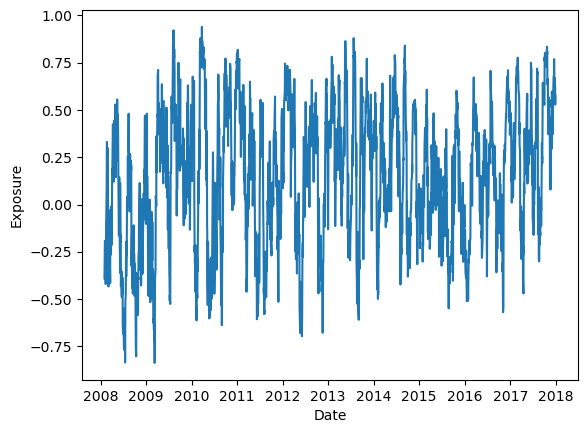

In [50]:
sns.lineplot(data = df['Exposure'])

In [51]:
(df['Exposure'] < 0).mean()

np.float64(0.3357171235597934)

In [52]:
df['Exposure'].corr(df['Pct Return'].shift(-1))

np.float64(-0.015609585074427836)

In [53]:
df['Rolling Entropy'].corr(df['Forward Vol'])

np.float64(0.2343593168864223)

<Axes: xlabel='Date'>

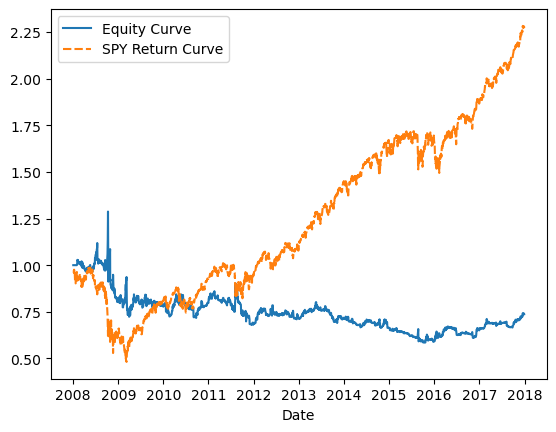

In [54]:
df['Exposure'] = df['T-Stat_20']
df['Exposure'].clip(0, 1)

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

In [55]:
(df['Exposure'] < 0).mean()

np.float64(0.3357171235597934)

<Axes: xlabel='Date'>

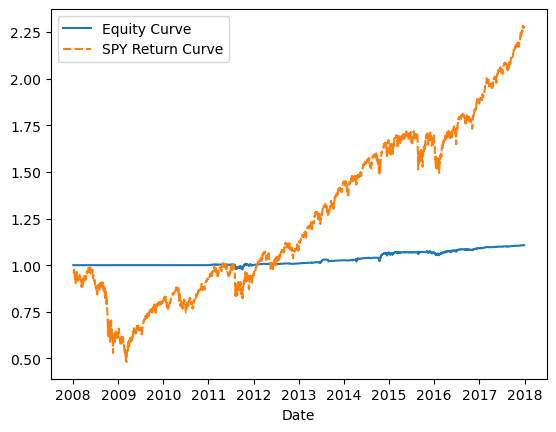

In [56]:
df['Exposure'] = df['Rolling Entropy']

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

In [57]:
import pandas as pd

df['Entropy Bins'] = pd.cut(df['Rolling Entropy'], bins = [0, 0.15, 0.4, 1], labels = ['Low', 'Mid', 'High'])

df.groupby('Entropy Bins')['Forward Vol'].mean().reset_index()

/var/folders/qd/xclxh05s0x9509nblm6z434w0000gp/T/ipykernel_11970/1836726988.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Entropy Bins')['Forward Vol'].mean().reset_index()


,Entropy Bins,Forward Vol
0,Low,0.007524
1,Mid,0.011115
2,High,0.007803


<Axes: xlabel='Date'>

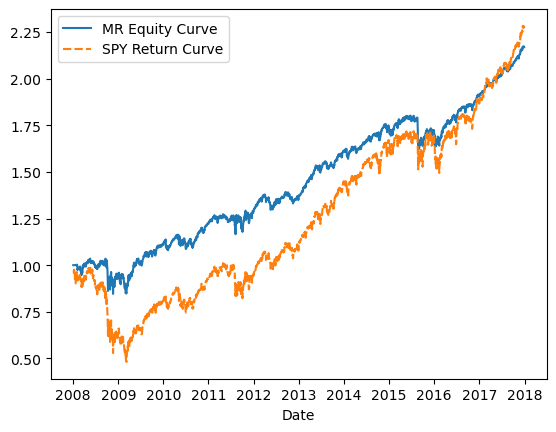

In [58]:
from backtests import mean_reversion
from features import zscore

df = zscore.calculate_zscore(df)
df = mean_reversion.generate_signal(df)
df = mean_reversion.mr_backtest(df)
sns.lineplot(data = df[['MR Equity Curve', 'SPY Return Curve']])

In [59]:
print(df['MR Signal'].describe())

count    2497.000000
mean        0.505244
std         0.202444
min         0.034192
25%         0.357388
50%         0.507389
75%         0.644160
max         0.977452
Name: MR Signal, dtype: float64


In [60]:
from evaluation import metrics

print(f"Mean-reversion-only Sharpe: {metrics.calculate_sharpe(df['MR Return'])}")
print(f"Mean-reversion-only max drawdown: {metrics.calculate_max_drawdown(df['MR Return'])}")

Mean-reversion-only Sharpe: 0.7438588830368342
Mean-reversion-only max drawdown: -0.1826337310808269


252


<Axes: xlabel='Date'>

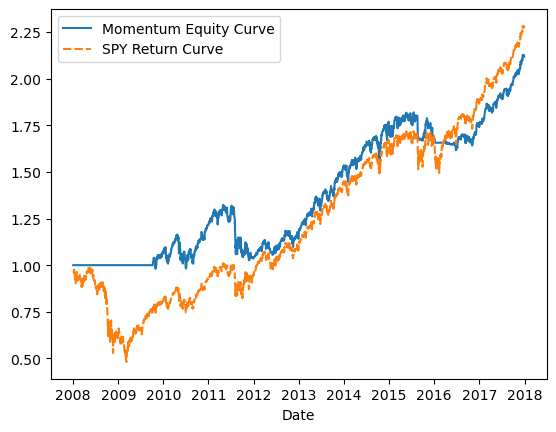

In [61]:
from backtests import momentum_backtest
from features import momentum

df = momentum.calculate_momentum(df)
df = momentum_backtest.generate_signal(df)
df = momentum_backtest.momentum_backtest(df)
sns.lineplot(data = df[['Momentum Equity Curve', 'SPY Return Curve']])

In [62]:
print(f"Momentum-only Sharpe: {metrics.calculate_sharpe(df['Momentum Return'])}")
print(f"Momentum-only max drawdown: {metrics.calculate_max_drawdown(df['Momentum Return'])}")

Momentum-only Sharpe: 0.6987982443716756
Momentum-only max drawdown: -0.22397676514735196


In [63]:
df['Momentum Signal'].describe()

count    2265.000000
mean        0.818675
std         0.359271
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Momentum Signal, dtype: float64

In [64]:
df['Momentum'].describe()

count    2265.000000
mean        0.099576
std         0.168280
min        -0.641582
25%         0.052112
50%         0.138260
75%         0.189540
max         0.541988
Name: Momentum, dtype: float64

In [65]:
print(f"SPY Sharpe: {metrics.calculate_sharpe(df['Pct Return'])}")
print(f"SPY max drawdown: {metrics.calculate_max_drawdown(df['Pct Return'])}")

SPY Sharpe: 0.5053320237705937
SPY max drawdown: -0.5148146521410742


<Axes: xlabel='Date'>

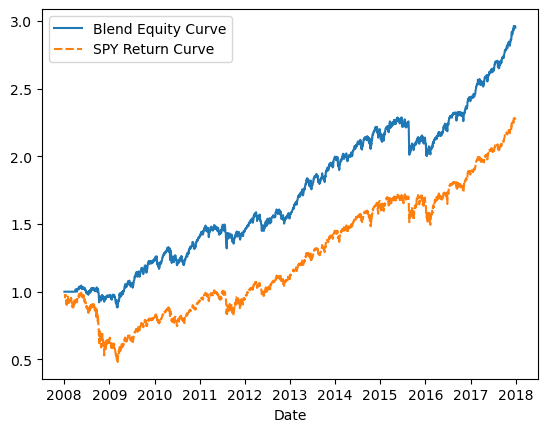

In [66]:
from backtests import blend_signal

df = blend_signal.generate_signal(df)
df = blend_signal.blended_backtest(df)
sns.lineplot(data = df[['Blend Equity Curve', 'SPY Return Curve']])

In [67]:
print(f"Blend Sharpe: {metrics.calculate_sharpe(df['Blend Return'])}")
print(f"Blend max drawdown: {metrics.calculate_max_drawdown(df['Blend Return'])}")

Blend Sharpe: 0.9990944919526431
Blend max drawdown: -0.15360267435265818


In [68]:
print(df['Confidence'].describe())
print(df['State'].value_counts())

count    2517.000000
mean        0.905448
std         0.105298
min         0.454190
25%         0.882347
50%         0.933183
75%         1.000000
max         1.000000
Name: Confidence, dtype: float64
State
1.0_0     1585
1.0_1      318
-1.0_0     252
0.0_0      200
-1.0_1     158
nan_0        4
Name: count, dtype: int64


[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

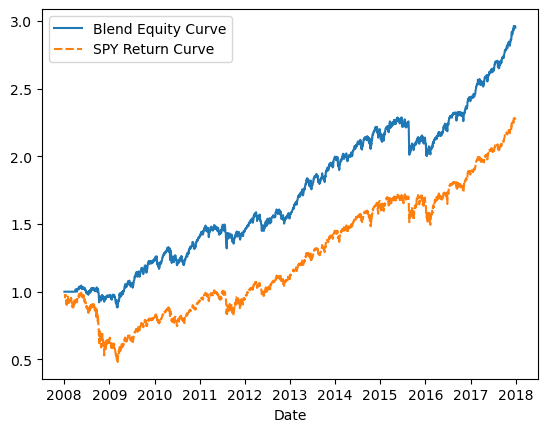

In [69]:
from pipeline import run

test = run.run_pipeline('SPY')

sns.lineplot(data = df[['Blend Equity Curve', 'SPY Return Curve']])

In [70]:
print(f'Blend annualized returns: {metrics.calculate_annualized_returns(df['Blend Return'])}')
print(f'Blend Sortino ratio: {metrics.calculate_sortino(df['Blend Return'])}')
print(f'Blend Calmar ratio: {metrics.calculate_calmar(df['Blend Return'])}')

Blend annualized returns: 0.11422033545208521
Blend Sortino ratio: 1.2865855746251116
Blend Calmar ratio: 0.7436090285110883


In [71]:
print(f'SPY annualized returns: {metrics.calculate_annualized_returns(df['Pct Return'])}')
print(f'SPY Sortino ratio: {metrics.calculate_sortino(df['Pct Return'])}')
print(f'SPY Calmar ratio: {metrics.calculate_calmar(df['Pct Return'])}')

SPY annualized returns: 0.08544717696405413
SPY Sortino ratio: 0.615437179469052
SPY Calmar ratio: 0.16597658323959105


In [72]:
df

,Price,Log Return,Return,T-Stat_200,Volatility,Vol State,Regime,Forward Return,Forward Vol,State,...,MR Signal,MR Return,MR Equity Curve,Momentum,Momentum Signal,Momentum Return,Momentum Equity Curve,Blend Signal,Blend Return,Blend Equity Curve
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-03,103.445656,-0.000483,NaN,NaN,NaN,0,NaN,-0.024812,NaN,nan_0,...,NaN,0.000000,1.000000,NaN,NaN,0.000000,1.000000,NaN,0.000000,1.000000
2008-01-04,100.910561,-0.024812,-0.024507,NaN,NaN,0,NaN,-0.000849,NaN,nan_0,...,NaN,0.000000,1.000000,NaN,NaN,0.000000,1.000000,NaN,0.000000,1.000000
2008-01-07,100.824898,-0.000849,-0.000849,NaN,NaN,0,NaN,-0.016281,NaN,nan_0,...,NaN,0.000000,1.000000,NaN,NaN,0.000000,1.000000,NaN,0.000000,1.000000
2008-01-08,99.196701,-0.016281,-0.016149,NaN,NaN,0,NaN,0.010456,NaN,nan_0,...,NaN,0.000000,1.000000,NaN,NaN,0.000000,1.000000,NaN,0.000000,1.000000
2008-01-09,100.239311,0.010456,0.010511,NaN,NaN,0,0.0,0.006532,NaN,0.0_0,...,NaN,0.000000,1.000000,NaN,NaN,0.000000,1.000000,NaN,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-22,235.453140,-0.000262,-0.000262,2.310020,0.003561,0,1.0,-0.001197,0.003566,1.0_0,...,0.481091,-0.000126,2.170285,0.189156,1.0,-0.000262,2.121927,1.0,-0.000262,2.956866
2017-12-26,235.171509,-0.001197,-0.001196,2.250610,0.003566,0,1.0,0.000487,0.003566,1.0_0,...,0.608505,-0.000728,2.168706,0.190624,1.0,-0.001196,2.119389,1.0,-0.001196,2.953329
2017-12-27,235.285950,0.000487,0.000487,2.221702,0.003566,0,1.0,0.002055,0.003542,1.0_0,...,0.657012,0.000320,2.169399,0.187964,1.0,0.000487,2.120420,1.0,0.000487,2.954766


<Axes: xlabel='Date', ylabel='Rolling Entropy'>

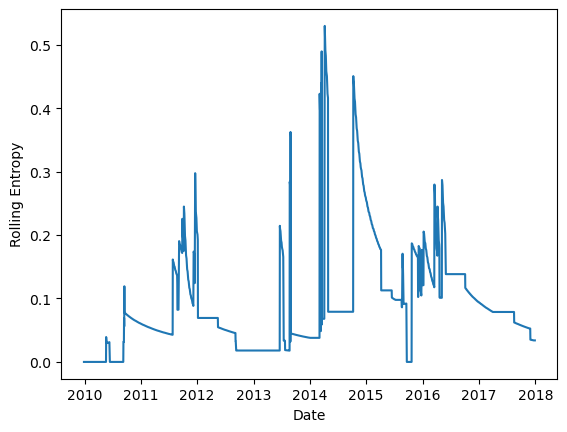

In [ ]:
df = entropy.build_rolling_entropy(df)

sns.lineplot(data = df['Rolling Entropy'])

Text(0, 0.5, 'SPY')

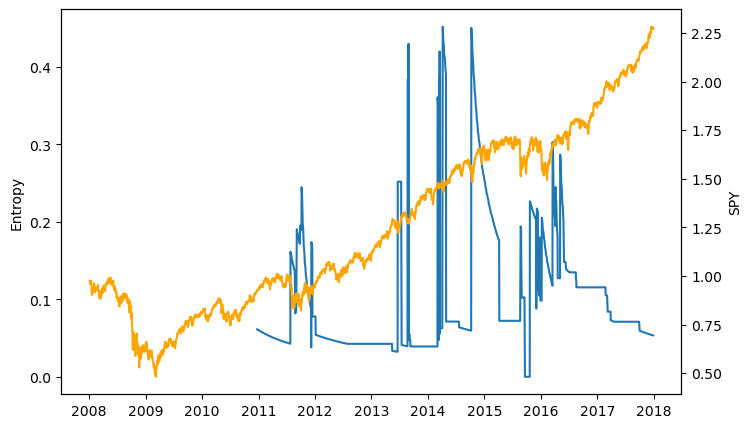

In [73]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['Rolling Entropy'], label = 'Entropy')
ax1.set_ylabel('Entropy')
ax2 = ax1.twinx()
ax2.plot(df['SPY Return Curve'], label = 'SPY', color = 'Orange')
ax2.set_ylabel('SPY')